# Full Skull + Brain Registration -- CPD + TPS (all bug fixes from this session applied)

This restores the **original full-pipeline scope**: a single warp field,
driven by head/face bone landmark correspondence, propagated to the **entire**
mesh at once -- skull AND brain deform together, maintaining anatomical
alignment. This is different from `CPD_TPS_Skin_Only_Registration.ipynb`,
which deliberately leaves the brain untouched.

Every bug found and fixed while debugging the skin-only notebook is carried
over here (see `CHANGELOG.md` for the full history of each):

- **PCA coarse pre-alignment** before rigid CPD -- without it, CPD can
  converge to a self-consistent but wrong rotation on near-symmetric anatomy.
- **Head/face bone scope, jaw+teeth excluded** -- the registration is driven
  by braincase + mid-face bones only (`frontal`/`parietal`/`temporal`/
  `occipital`/`sphenoid`/`ethmoid`/`lacrimal`/`nasal`/`zygomatic`/`maxilla`);
  `mandible`/teeth/`alveolar`/`palatine` have no clean skin correspondence
  and produced a hanging-down artifact when included.
- **Affine singular-value clamp** -- prevents the affine CPD stage from
  overfitting into an implausible shear/scale on a sparse landmark set.
- **Confidence-damped blend with spatial smoothing** -- the external
  surface's local ICP refinement is blended against the smooth TPS baseline
  per point, comparing warped-vs-original residual directly (not a fixed
  threshold), and the confidence field itself is spatially smoothed so
  mesh-adjacent points don't diverge and tear.

**One structural difference from the skin-only notebook, by design:** there
is no "frozen boundary" step here. In the skin-only notebook, freezing the
brain (and jaw/teeth) at the skull boundary was necessary specifically
*because* the brain was not supposed to move at all -- so any skull node
touching brain had to freeze too, or the shared element tears. Here, the
opposite fix applies: since the smooth TPS field is evaluated on **every**
node of the mesh (skull, brain, jaw, teeth, everything), nothing is left
behind, so there is nothing to tear against. Only the head/face **external**
surface gets an additional local refinement (ICP + confidence blend) on top
of that same smooth baseline -- everything else, brain included, moves
coherently with the single global TPS field.

```
Template .k (skull+brain) ──┐
                              ├─ EXTRACT head+face external surface only
                              │  (drives registration; jaw/teeth excluded)
SAM3D landmarks (subject) ───┘
        │
        ▼
Stage 0 — Center + resize
        ▼
Stage 1 — PCA coarse pre-alignment
        ▼
Stage 2 — Rigid CPD
        ▼
Stage 3 — Affine CPD (singular values clamped)
        ▼
Stage 4 — Non-rigid CPD
        ▼
Stage 5 — TPS propagation to the ENTIRE mesh (skull + brain + everything)
        ▼
Stage 6 — Non-rigid ICP refinement (external head/face surface only)
        ▼
Stage 6.5 — Confidence-damped blend (external surface only, do-no-harm)
        ▼
Stage 7 — Validation (NN/Chamfer/Hausdorff + k_mesh_qa.py baseline-delta check)
        ▼
Final .vtu — every node updated; external surface gets the refined result,
             everything else (brain included) gets the smooth TPS warp
```


## Setup

On Apple Silicon (M2), `pyvista`/`vtk` and `pycpd` all have native arm64 wheels — no Rosetta/x86 workaround needed.

In [1]:
!pip install pycpd pyvista numpy scipy matplotlib pandas -q

import os, sys
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import cKDTree
from scipy.interpolate import RBFInterpolator
from pycpd import RigidRegistration, AffineRegistration, DeformableRegistration

np.random.seed(0)
print('pyvista:', pv.__version__)
print('numpy  :', np.__version__)

pyvista: 0.48.4
numpy  : 2.3.5


## Configuration

In [2]:
BASE_DIR = r'/Volumes/Extreme SSD/2d_3d_regis dataset/New_version'

TEMPLATE_K    = os.path.join(BASE_DIR, 'Head_V6.k')
TEMPLATE_VTU  = os.path.join(BASE_DIR, 'Data/outputs/vtk_export/Head_V6.vtu')

# TODO: point this at the real SAM3D landmark export once available.
SUBJECT_LANDMARKS_PATH = os.path.join(BASE_DIR, 'Data/subject_landmarks.npy')
# Placeholder fallback ONLY used if SUBJECT_LANDMARKS_PATH doesn't exist yet:
FALLBACK_SUBJECT_FILE = r'/Volumes/Extreme SSD/Head_model/head_surface.key'  # outer head skin only
N_FALLBACK_SAMPLES = 3000

OUTPUT_DIR = os.path.join(BASE_DIR, 'Data/outputs/cpd_tps_full_registration')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Head/face bone PID range to search within (facial/cranial bone)
SKULL_SURFACE_PID_MIN, SKULL_SURFACE_PID_MAX = 88000001, 88000099

N_LANDMARKS_FIXED  = 2000
N_LANDMARKS_MOVING = 2000

CPD_ALPHA = 2.0
CPD_BETA  = 2.0
CPD_MAX_ITER = 100
CPD_TOL = 1e-6

TPS_SMOOTHING = 1e-3

# Lightweight non-rigid ICP refinement (Stage 6, external surface only)
ICP_ITERS = 10
ICP_MAX_CORR_DIST_MM = 15.0
ICP_STEP = 0.5
ICP_SMOOTH_NEIGHBORS = 8

print('Template .k  exists:', os.path.exists(TEMPLATE_K))
print('Template .vtu exists:', os.path.exists(TEMPLATE_VTU))
print('Subject landmarks   :', os.path.exists(SUBJECT_LANDMARKS_PATH), '(fallback will be used if False)')

Template .k  exists: True
Template .vtu exists: True
Subject landmarks   : False (fallback will be used if False)


## Load template geometry + extract head/face external surface (jaw + teeth excluded)

Only the driving-registration surface is filtered (head/face external bones,
same `HEAD_FACE_INCLUDE_PREFIXES` scope as the skin-only notebook -- braincase
+ mid-face, `mandible`/teeth/`alveolar`/`palatine` excluded since they have no
clean skin correspondence). The **propagation target is the entire mesh** --
every node, including brain -- so there is no separate "full skull volume" or
"frozen boundary" concept needed here.

In [3]:
import re

HEAD_FACE_INCLUDE_PREFIXES = (
    'frontal', 'parietal', 'temporal', 'occipital', 'sphenoid', 'ethmoid',  # braincase
    'lacrimal', 'nasal', 'zygomatic', 'maxilla',                            # mid-face, has real skin counterpart
)
# Explicitly excluded: mandible (jaw), palatine, teeth-lwr/upr, alveolar,
# str1-7/ng-str/ng-str2 -- no outer-skin correspondence.

def parse_part_names(k_path):
    names = {}
    with open(k_path, errors='ignore') as f:
        for line in f:
            if line.startswith('$HMNAME COMPS'):
                m = re.match(r'\$HMNAME COMPS\s*(\d+)(.*)', line.strip())
                if m:
                    names[int(m.group(1))] = m.group(2).strip()
    return names

def matches_include_list(name, include_prefixes):
    return any(name.startswith(p) for p in include_prefixes)

PART_NAMES = parse_part_names(TEMPLATE_K)

SKULL_EXTERNAL_PIDS = [
    pid for pid in range(SKULL_SURFACE_PID_MIN, SKULL_SURFACE_PID_MAX + 1)
    if '_external_' in PART_NAMES.get(pid, '') and matches_include_list(PART_NAMES.get(pid, ''), HEAD_FACE_INCLUDE_PREFIXES)
]

template_mesh = pv.read(TEMPLATE_VTU)
print(f'Template: {template_mesh.n_points:,} pts, {template_mesh.n_cells:,} cells')
print(f'External-only head/face PIDs found: {len(SKULL_EXTERNAL_PIDS)} -> {SKULL_EXTERNAL_PIDS}')

pids = template_mesh.cell_data['part_id']

# External surface only -- drives the registration (real subject correspondence)
ext_cells = np.where(np.isin(pids, SKULL_EXTERNAL_PIDS))[0]
skull_sub = template_mesh.extract_cells(ext_cells)
skull_surf = skull_sub.extract_surface(algorithm='dataset_surface').triangulate()
skull_surf_node_ids = skull_surf.point_data['node_id']
skull_surf_pts0     = np.asarray(skull_surf.points, dtype=np.float64)

# Propagation target: the ENTIRE mesh, in the template's own node order
mesh_node_ids = np.asarray(template_mesh.point_data['node_id'])
mesh_pts0     = np.asarray(template_mesh.points, dtype=np.float64)

full_nid_to_idx = {int(nid): i for i, nid in enumerate(mesh_node_ids)}
external_idx_in_full = np.array([full_nid_to_idx[int(nid)] for nid in skull_surf_node_ids])

print(f'\nExternal surface (drives registration): {skull_surf.n_points:,} pts')
print(f'Entire mesh (gets warped, skull+brain+everything): {len(mesh_node_ids):,} pts')

Template: 179,676 pts, 256,571 cells
External-only head/face PIDs found: 18 -> [88000002, 88000005, 88000009, 88000012, 88000015, 88000019, 88000022, 88000028, 88000031, 88000053, 88000056, 88000060, 88000063, 88000066, 88000069, 88000072, 88000077, 88000080]

External surface (drives registration): 10,029 pts
Entire mesh (gets warped, skull+brain+everything): 179,676 pts


## Load subject landmarks (SAM3D, with placeholder fallback)

In [4]:
def load_subject_landmarks(path, fallback_path, n_fallback):
    if os.path.exists(path):
        if path.endswith('.npy'):
            pts = np.load(path)
        else:
            pts = np.loadtxt(path, delimiter=',') if path.endswith('.csv') else np.loadtxt(path)
        print(f'Loaded {len(pts):,} SAM3D landmarks from {path}')
        return np.asarray(pts, dtype=np.float64)

    print(f'⚠ {path} not found -- SAM3D landmarks not wired in yet.')
    print(f'  Falling back to {fallback_path}')
    print('  Replace SUBJECT_LANDMARKS_PATH once SAM3D output is available.')

    if fallback_path.endswith(('.k', '.key')):
        sys.path.insert(0, os.path.join(BASE_DIR, 'Code'))
        from k_mesh_qa import parse_k_file
        fb_nodes, _, _ = parse_k_file(fallback_path)
        fb_pts = np.array(list(fb_nodes.values()), dtype=np.float64)
    else:
        fb_mesh = pv.read(fallback_path)
        fb_pts = np.asarray(fb_mesh.points, dtype=np.float64)

    print(f'  Fallback surface: {len(fb_pts):,} points total')
    idx = np.random.choice(len(fb_pts), min(n_fallback, len(fb_pts)), replace=False)
    return fb_pts[idx]

subject_pts = load_subject_landmarks(SUBJECT_LANDMARKS_PATH, FALLBACK_SUBJECT_FILE, N_FALLBACK_SAMPLES)
print(f'Subject point set: {subject_pts.shape}')

⚠ /Volumes/Extreme SSD/2d_3d_regis dataset/New_version/Data/subject_landmarks.npy not found -- SAM3D landmarks not wired in yet.
  Falling back to /Volumes/Extreme SSD/Head_model/head_surface.key
  Replace SUBJECT_LANDMARKS_PATH once SAM3D output is available.
  Fallback surface: 6,182 points total
Subject point set: (3000, 3)


## Stage 0 — Center + resize

Centroid (subject) : [-180.     1.1  690.4]
Centroid (template): [-180.4    0.   665.6]
Scale factor        : 1.2081


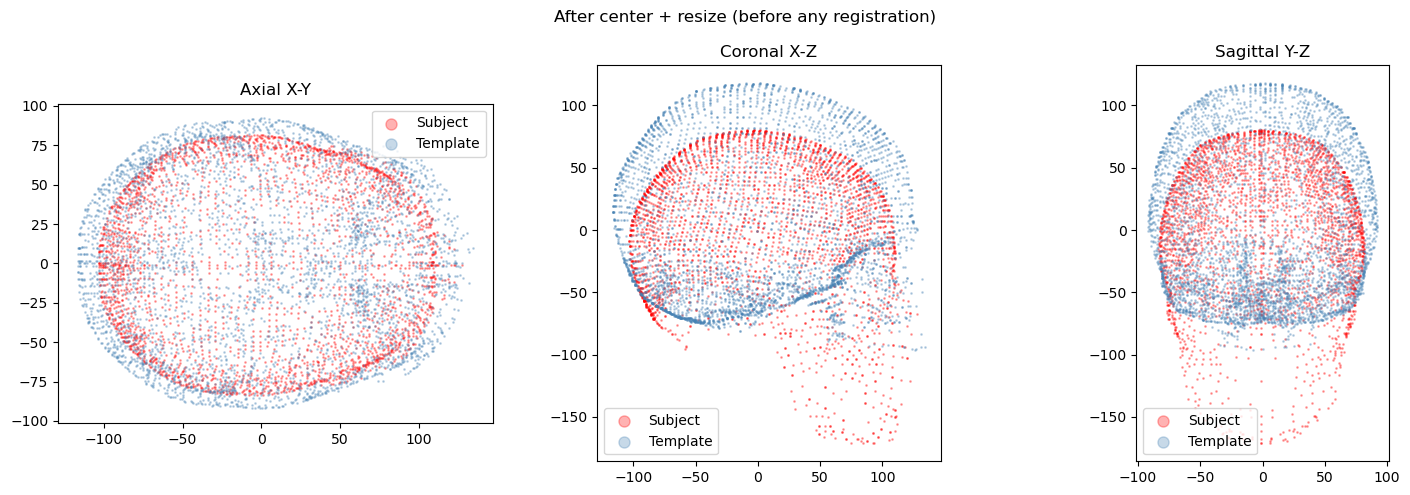

In [5]:
def center_and_scale(fixed_pts, moving_pts):
    c_fixed  = fixed_pts.mean(0)
    c_moving = moving_pts.mean(0)
    f_c = fixed_pts - c_fixed
    m_c = moving_pts - c_moving
    diag_f = np.linalg.norm(f_c.max(0) - f_c.min(0))
    diag_m = np.linalg.norm(m_c.max(0) - m_c.min(0))
    scale = diag_f / (diag_m + 1e-8)
    return f_c, m_c * scale, dict(c_fixed=c_fixed, c_moving=c_moving, scale=scale)

# Basis for centering/scale is still the EXTERNAL surface vs subject (the only
# pair with real correspondence) -- the entire mesh is then carried through
# the exact same transform so everything stays in one consistent frame.
nf_c, nm_surf_cs, norm_params = center_and_scale(subject_pts, skull_surf_pts0)
c_fixed, c_moving, scale = norm_params['c_fixed'], norm_params['c_moving'], norm_params['scale']
nm_full_cs = (mesh_pts0 - c_moving) * scale

print(f'Centroid (subject) : {c_fixed.round(1)}')
print(f'Centroid (template): {c_moving.round(1)}')
print(f'Scale factor        : {scale:.4f}')

def plot_overlap(a, b, title, labels=('Subject', 'Template'), n_sample=4000):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    views = [(0, 1, 'Axial X-Y'), (0, 2, 'Coronal X-Z'), (1, 2, 'Sagittal Y-Z')]
    sa = np.random.choice(len(a), min(n_sample, len(a)), replace=False)
    sb = np.random.choice(len(b), min(n_sample, len(b)), replace=False)
    for ax, (i, j, lbl) in zip(axes, views):
        ax.scatter(a[sa, i], a[sa, j], s=1, c='red', alpha=0.3, label=labels[0])
        ax.scatter(b[sb, i], b[sb, j], s=1, c='steelblue', alpha=0.3, label=labels[1])
        ax.set_title(lbl); ax.set_aspect('equal'); ax.legend(markerscale=8)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

plot_overlap(nf_c, nm_surf_cs, 'After center + resize (before any registration)')

## Stage 0.5 — Landmark subsampling (farthest-point sampling)

Fixed  (subject) landmarks : 2,000
Moving (template) landmarks: 2,000


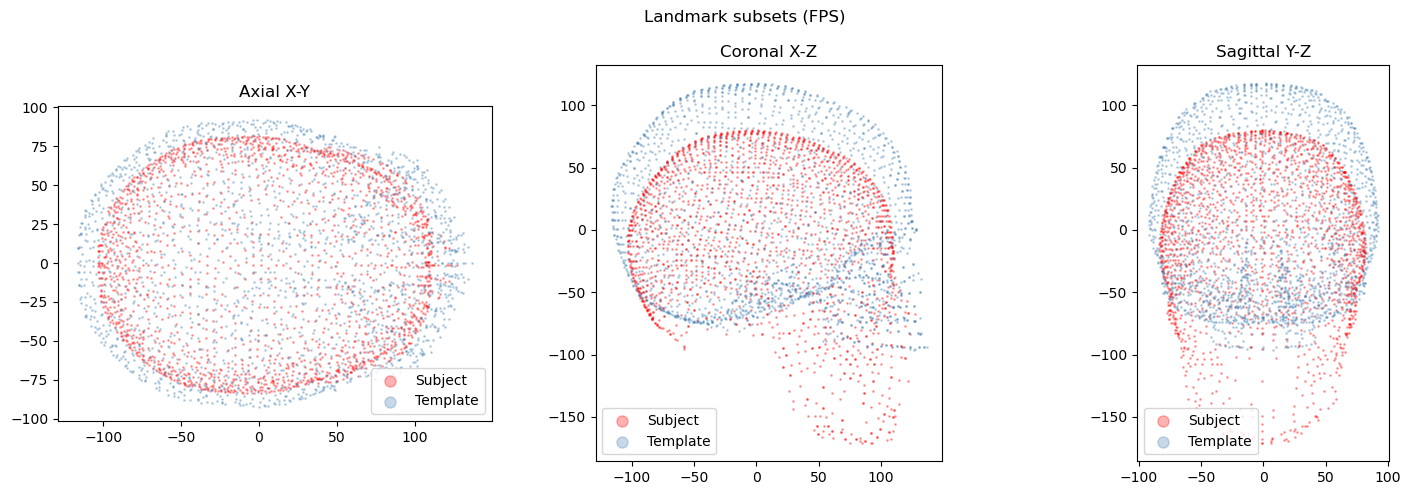

In [6]:
def farthest_point_sampling(points, n_samples, seed=0):
    rng = np.random.default_rng(seed)
    n = len(points)
    n_samples = min(n_samples, n)
    selected = np.empty(n_samples, dtype=np.int64)
    selected[0] = rng.integers(n)
    dist = np.linalg.norm(points - points[selected[0]], axis=1)
    for k in range(1, n_samples):
        selected[k] = np.argmax(dist)
        dist = np.minimum(dist, np.linalg.norm(points - points[selected[k]], axis=1))
    return selected

fixed_lm_idx  = farthest_point_sampling(nf_c, N_LANDMARKS_FIXED)
moving_lm_idx = farthest_point_sampling(nm_surf_cs, N_LANDMARKS_MOVING)

fixed_lm  = nf_c[fixed_lm_idx]
moving_lm = nm_surf_cs[moving_lm_idx]

print(f'Fixed  (subject) landmarks : {len(fixed_lm):,}')
print(f'Moving (template) landmarks: {len(moving_lm):,}')
plot_overlap(fixed_lm, moving_lm, 'Landmark subsets (FPS)')

## Stage 1 — PCA coarse pre-alignment

CPD is a local optimizer and heads are near-bilaterally-symmetric -- without
a decent initial pose, rigid CPD can converge to a self-consistent but wrong
rotation. PCA-align the principal axes first, resolving the sign/reflection
ambiguity by testing the 4 valid proper-rotation candidates.

PCA pre-alignment rotation (best of 4 valid sign combinations):
[[-0.989  0.077 -0.125]
 [ 0.058  0.987  0.147]
 [ 0.135  0.139 -0.981]]
Mean NN distance after PCA align: 16.05 (normalized units)


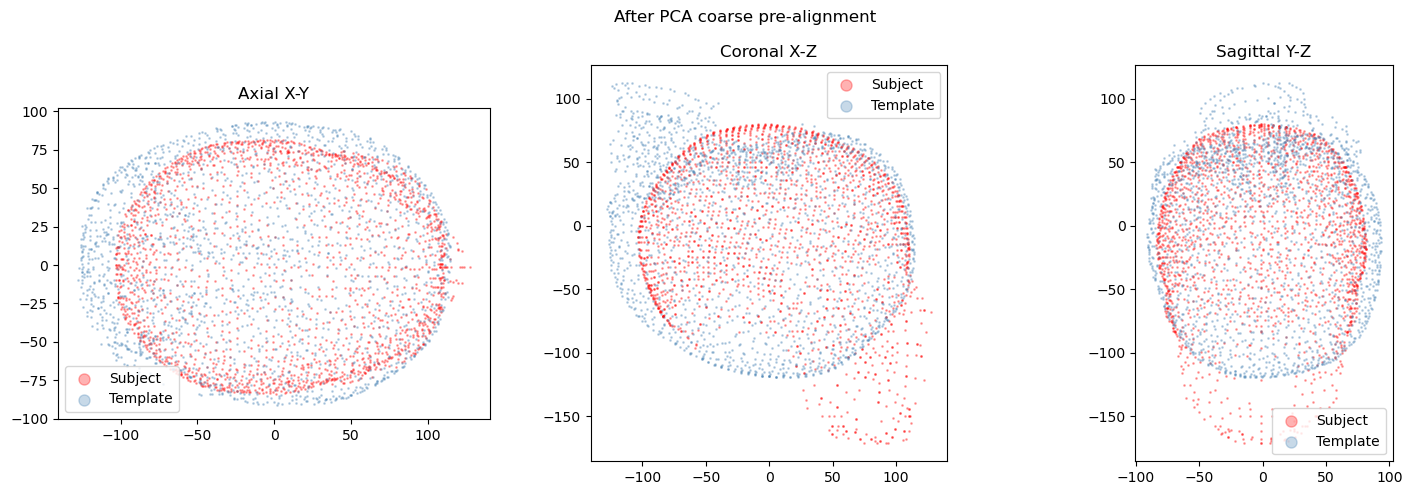

In [7]:
def pca_axes(pts):
    cov = np.cov(pts.T)
    w, v = np.linalg.eigh(cov)
    order = np.argsort(w)[::-1]
    return v[:, order]

def pca_prealign(fixed_pts, moving_pts, eval_stride=5):
    V_f = pca_axes(fixed_pts)
    V_m = pca_axes(moving_pts)
    tree = cKDTree(fixed_pts)
    best = None
    for s0 in (1, -1):
        for s1 in (1, -1):
            for s2 in (1, -1):
                S = np.diag([s0, s1, s2])
                R = V_f @ S @ V_m.T
                if np.linalg.det(R) < 0:
                    continue  # reflection, not a valid rotation
                cand = moving_pts @ R.T
                d, _ = tree.query(cand[::eval_stride])
                score = d.mean()
                if best is None or score < best[0]:
                    best = (score, R)
    return best[1], best[0]

R_pca, pca_score = pca_prealign(fixed_lm, moving_lm)
print(f'PCA pre-alignment rotation (best of 4 valid sign combinations):')
print(np.round(R_pca, 3))
print(f'Mean NN distance after PCA align: {pca_score:.2f} (normalized units)')

moving_lm_pca  = moving_lm  @ R_pca.T
nm_surf_pca    = nm_surf_cs @ R_pca.T   # dense external surface, consistent with the landmark subset
nm_full_pca    = nm_full_cs @ R_pca.T   # ENTIRE mesh (skull+brain+everything), same transform

plot_overlap(fixed_lm, moving_lm_pca, 'After PCA coarse pre-alignment')

## Stage 2 — Rigid CPD

Rigid scale       : 0.9595
Rigid rotation R  :
[[ 0.947  0.061 -0.316]
 [-0.056  0.998  0.026]
 [ 0.317 -0.007  0.948]]
Rigid translation : [ 19.95  -3.97 -14.38]


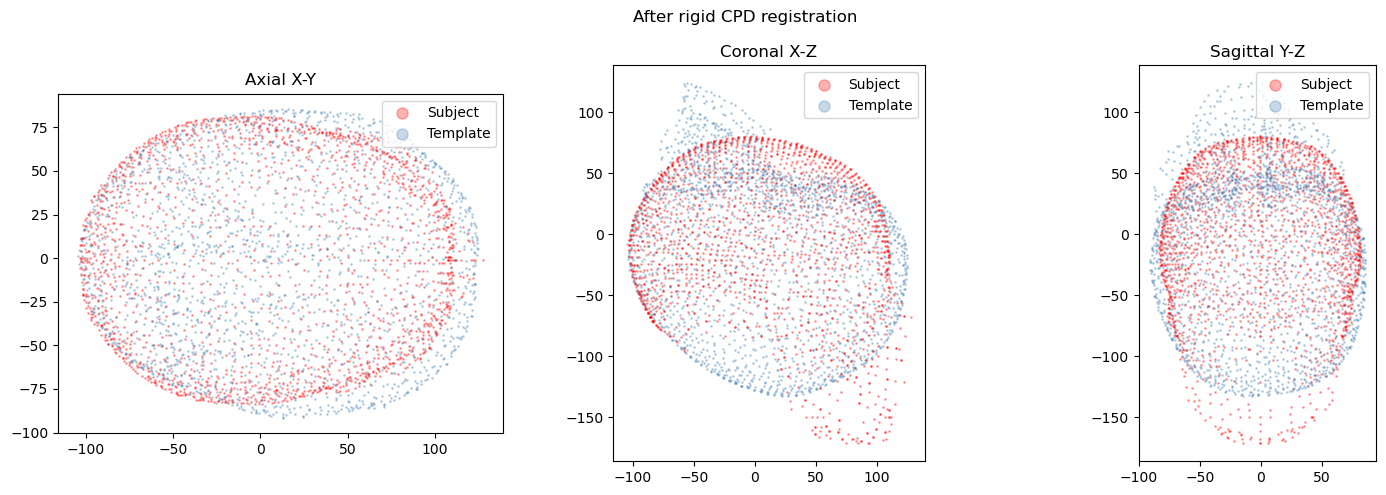

In [8]:
rigid_reg = RigidRegistration(X=fixed_lm, Y=moving_lm_pca, max_iterations=CPD_MAX_ITER, tolerance=CPD_TOL)
TY_rigid, (s_r, R_r, t_r) = rigid_reg.register()

print(f'Rigid scale       : {s_r:.4f}')
print(f'Rigid rotation R  :\n{np.round(R_r, 3)}')
print(f'Rigid translation : {np.round(t_r, 2)}')

plot_overlap(fixed_lm, TY_rigid, 'After rigid CPD registration')

## Stage 3 — Affine CPD (singular values clamped)

Affine matrix B (raw)    :
[[ 0.875  0.007  0.232]
 [ 0.026  0.912 -0.04 ]
 [-0.455  0.035  1.351]]
Singular values (raw)    : [1.428 0.918 0.896]
Singular values (clamped): [1.25  0.918 0.896]
Affine translation: [-16.1    1.23   4.69]


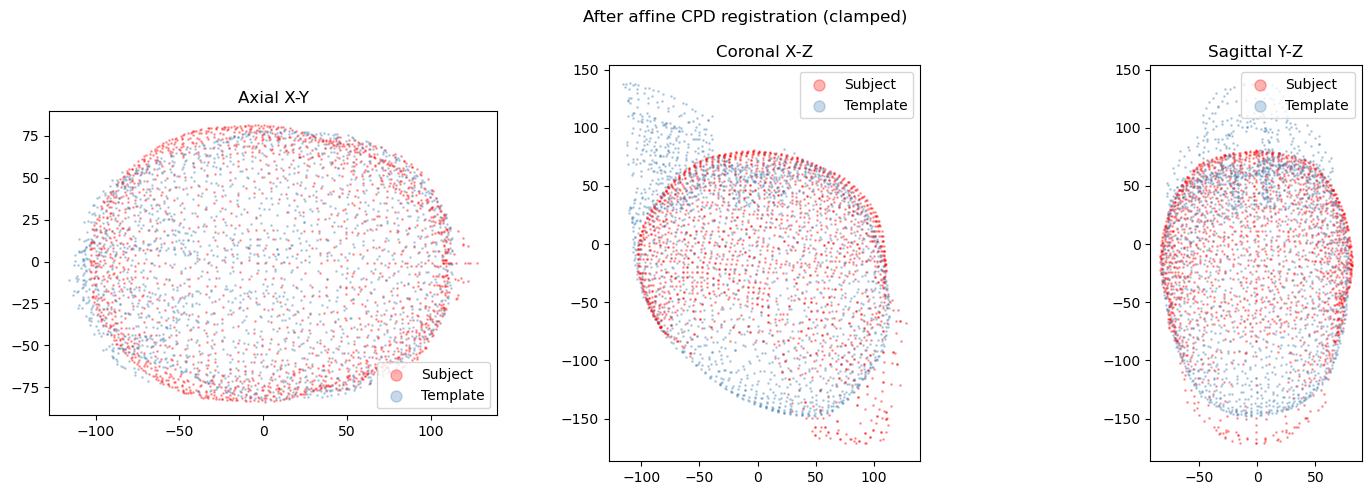

In [9]:
AFFINE_SINGULAR_VALUE_CLAMP = (0.8, 1.25)  # reject implausible shear/scale (overfitting a sparse landmark set)

affine_reg = AffineRegistration(X=fixed_lm, Y=TY_rigid, max_iterations=CPD_MAX_ITER, tolerance=CPD_TOL)
_, (B_a, t_a) = affine_reg.register()

# Clamp singular values of B: an unconstrained affine fit on a small/sparse
# landmark set can overfit into an anatomically implausible shear or
# axis-scale. Clamping keeps the transform close to similarity while still
# allowing modest anisotropy.
U, S, Vt = np.linalg.svd(B_a)
S_clamped = np.clip(S, *AFFINE_SINGULAR_VALUE_CLAMP)
B_a_clamped = U @ np.diag(S_clamped) @ Vt
TY_affine = TY_rigid @ B_a_clamped + t_a

print(f'Affine matrix B (raw)    :\n{np.round(B_a, 3)}')
print(f'Singular values (raw)    : {np.round(S, 3)}')
print(f'Singular values (clamped): {np.round(S_clamped, 3)}')
print(f'Affine translation: {np.round(t_a, 2)}')

plot_overlap(fixed_lm, TY_affine, 'After affine CPD registration (clamped)')

## Stage 4 — Non-rigid (deformable) CPD

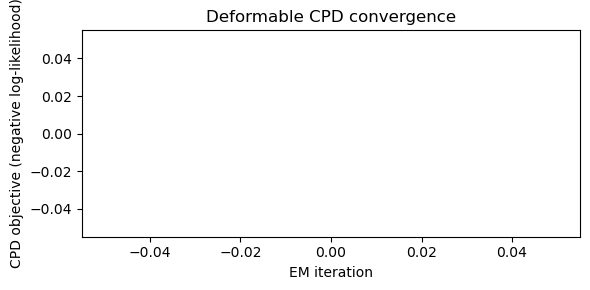

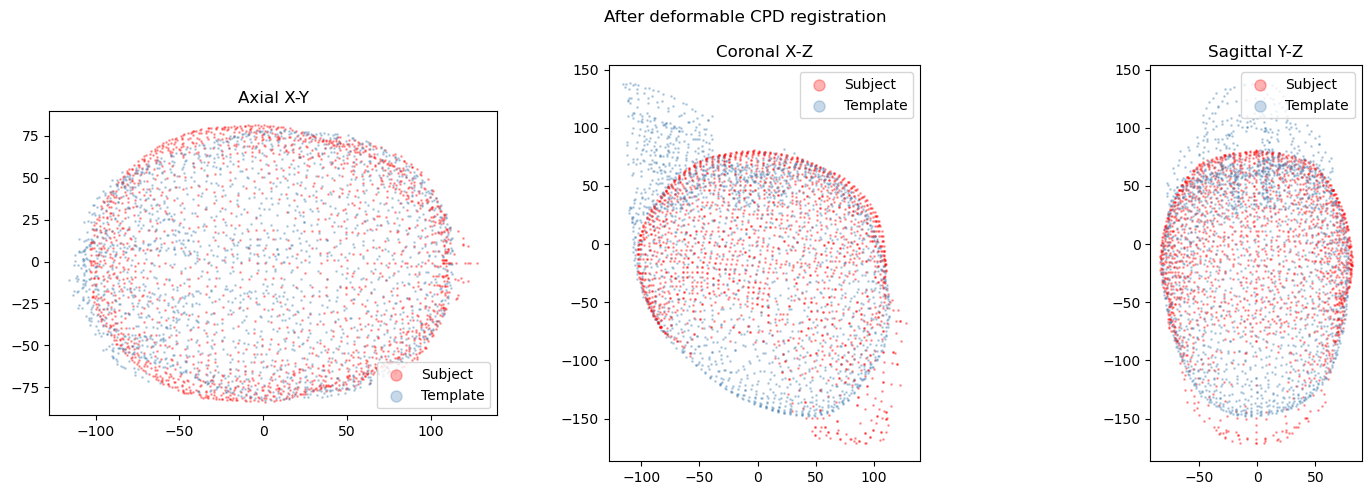

In [10]:
cpd_errors = []
def _track(iteration, error, X, Y):
    cpd_errors.append(error)

deformable_reg = DeformableRegistration(X=fixed_lm, Y=TY_affine,
                                         alpha=CPD_ALPHA, beta=CPD_BETA,
                                         max_iterations=CPD_MAX_ITER, tolerance=CPD_TOL)
TY_cpd, (G, W) = deformable_reg.register(callback=_track)

plt.figure(figsize=(6, 3))
plt.plot(cpd_errors)
plt.xlabel('EM iteration'); plt.ylabel('CPD objective (negative log-likelihood)')
plt.title('Deformable CPD convergence'); plt.tight_layout(); plt.show()

plot_overlap(fixed_lm, TY_cpd, 'After deformable CPD registration')

## Stage 5 — TPS propagation to the ENTIRE mesh (skull + brain + everything)

Fit TPS on the Stage-4 landmark displacements, then evaluate it on **every
node of the mesh** -- not just the head/face surface. Because the same
smooth field is applied everywhere, skull and brain deform together
consistently, with no frozen/moved boundary to tear at (unlike the
skin-only notebook, where the brain was deliberately left completely
still).

Warped entire mesh      : 179,676 nodes (skull + brain + everything)
Warped external surface : 10,029 nodes (subset used for local refinement)


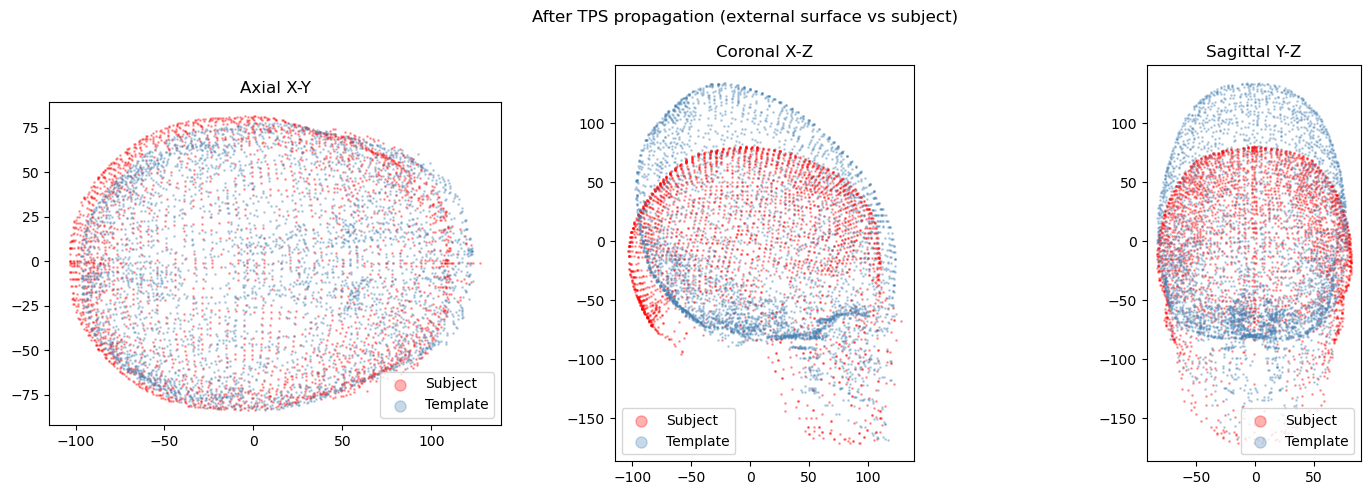

In [11]:
tps = RBFInterpolator(moving_lm, TY_cpd, kernel='thin_plate_spline', smoothing=TPS_SMOOTHING)

mesh_full_warped_cs = tps(nm_full_pca)                      # entire mesh
nm_surf_warped_cs = mesh_full_warped_cs[external_idx_in_full]  # external subset, for Stage 6/6.5 local refinement

print(f'Warped entire mesh      : {mesh_full_warped_cs.shape[0]:,} nodes (skull + brain + everything)')
print(f'Warped external surface : {nm_surf_warped_cs.shape[0]:,} nodes (subset used for local refinement)')
plot_overlap(nf_c, nm_surf_warped_cs, 'After TPS propagation (external surface vs subject)')

## Stage 6 — Non-rigid ICP refinement (external head/face surface only)

Local polish: pull each warped external-surface point toward its nearest
subject point, ignoring correspondences beyond `ICP_MAX_CORR_DIST_MM`, then
k-NN graph-smooth the pull field so the surface moves coherently. This is a
simplified stand-in for the full Amberg et al. (2007) optimal-step non-rigid
ICP. Only applied to the external surface -- brain and everything else keep
the Stage 5 TPS result as-is.

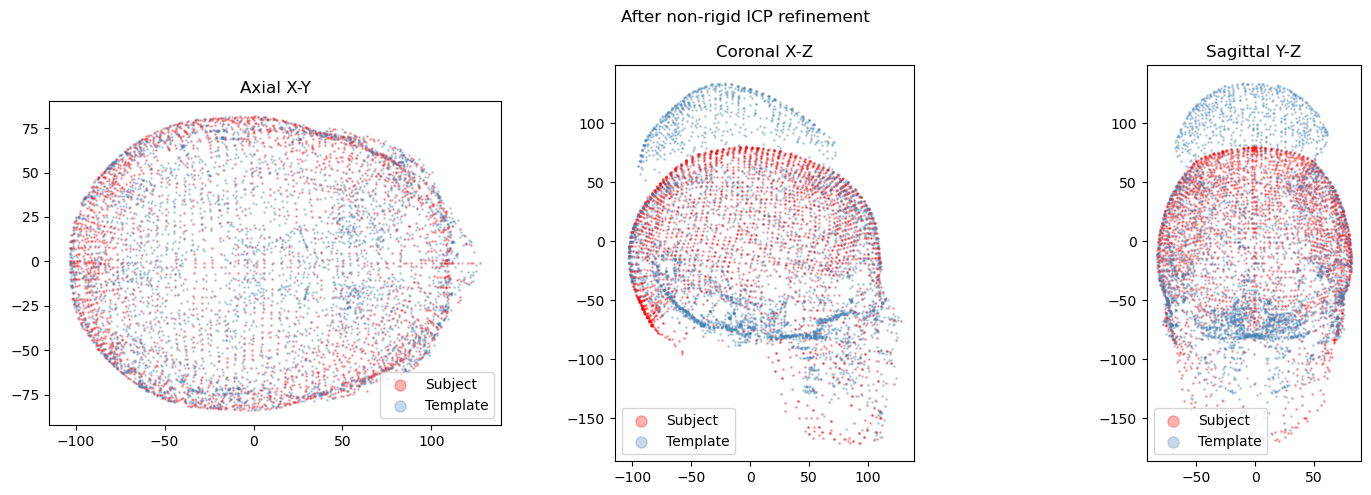

In [12]:
def graph_smooth(vectors, points, k=8, iters=1):
    tree = cKDTree(points)
    _, idx = tree.query(points, k=k + 1)  # includes self
    smoothed = vectors.copy()
    for _ in range(iters):
        smoothed = smoothed[idx].mean(axis=1)
    return smoothed

def nonrigid_icp_refine(source_pts, target_pts, iters, max_corr_dist_mm, step, scale, k_smooth):
    pts = source_pts.copy()
    tree_t = cKDTree(target_pts)
    for it in range(iters):
        d, nn_idx = tree_t.query(pts)
        pull = target_pts[nn_idx] - pts
        valid = (d / scale) < max_corr_dist_mm
        pull[~valid] = 0.0
        pull_smooth = graph_smooth(pull, pts, k=k_smooth)
        pts = pts + step * pull_smooth
    return pts

nm_surf_icp_cs = nonrigid_icp_refine(
    nm_surf_warped_cs, nf_c,
    iters=ICP_ITERS, max_corr_dist_mm=ICP_MAX_CORR_DIST_MM,
    step=ICP_STEP, scale=scale, k_smooth=ICP_SMOOTH_NEIGHBORS,
)

plot_overlap(nf_c, nm_surf_icp_cs, 'After non-rigid ICP refinement')

## Stage 6.5 -- Confidence-damped blend (do-no-harm safeguard, external surface only)

Compares each external-surface point's residual **at the warped position**
against its residual **at the original position** directly, and blends
toward whichever is actually closer (not a fixed threshold -- an earlier
version of this logic that thresholded on the warped residual alone
sometimes reverted to a worse original position; fixed in the skin-only
notebook and carried over here). The confidence field is spatially smoothed
across the mesh (k-NN graph) so mesh-adjacent points don't diverge sharply
and tear the surface between them.

Warp kept in full (warp was better)  : 2,646 / 10,029 points
Reverted to original (original was better): 3,263 / 10,029 points
Partially blended                     : 4,120 / 10,029 points
Confidence changed by smoothing -- mean 0.035, max 0.920, 1,239 points shifted by >0.1
Do-no-harm check -- mean residual: original=11.46mm  warped=14.18mm  blended=8.91mm
                     max residual : original=62.99mm  warped=56.26mm  blended=65.51mm


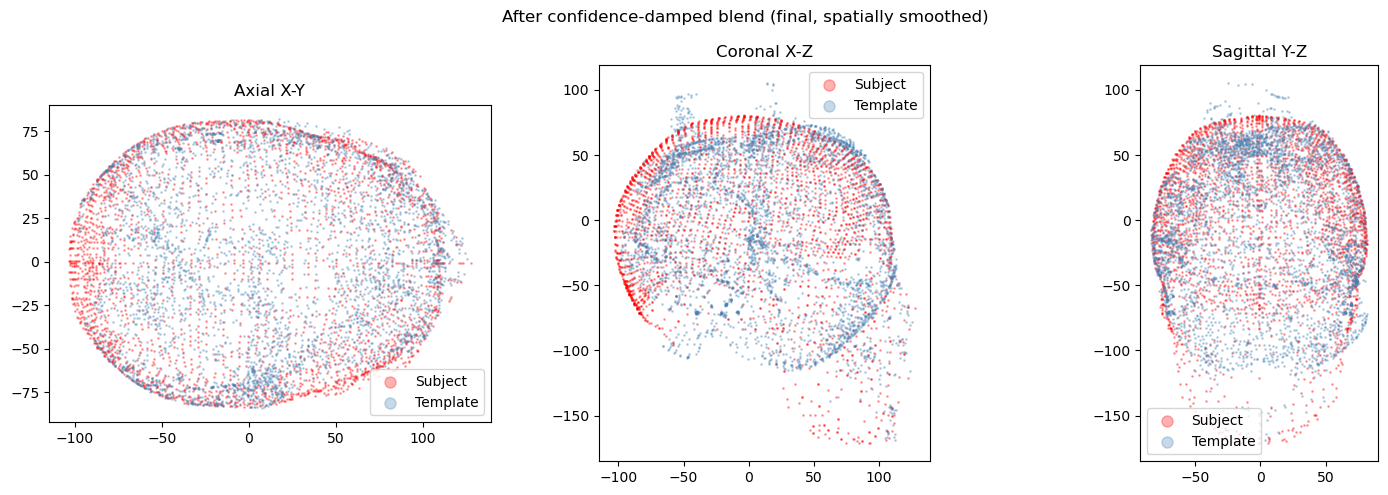

In [13]:
BLEND_TRANSITION_MM = 10.0
CONF_SMOOTH_NEIGHBORS = 8
CONF_SMOOTH_ITERS = 3

def coverage_damped_blend(original_pts, warped_pts, target_pts, scale,
                           transition_mm=BLEND_TRANSITION_MM,
                           smooth_k=CONF_SMOOTH_NEIGHBORS, smooth_iters=CONF_SMOOTH_ITERS):
    tree_t = cKDTree(target_pts)
    d_orig_mm, _   = tree_t.query(original_pts)
    d_warped_mm, _ = tree_t.query(warped_pts)
    d_orig_mm   /= scale
    d_warped_mm /= scale

    advantage = d_orig_mm - d_warped_mm   # positive => warp is better
    confidence_raw = np.clip(advantage / transition_mm + 0.5, 0.0, 1.0)

    tree_p = cKDTree(warped_pts)
    _, knn_idx = tree_p.query(warped_pts, k=smooth_k + 1)
    confidence = confidence_raw.copy()
    for _ in range(smooth_iters):
        confidence = confidence[knn_idx].mean(axis=1)

    blended = original_pts + confidence[:, None] * (warped_pts - original_pts)

    d_blended_mm, _ = tree_t.query(blended)
    d_blended_mm /= scale
    return blended, confidence, confidence_raw, d_orig_mm, d_warped_mm, d_blended_mm

nm_surf_final_cs, coverage_conf, coverage_conf_raw, d_orig_mm, d_warped_mm, d_blended_mm = coverage_damped_blend(
    nm_surf_pca, nm_surf_icp_cs, nf_c, scale)

n_warp_kept = int((coverage_conf >= 0.999).sum())
n_reverted  = int((coverage_conf <= 0.001).sum())
n_blend     = len(coverage_conf) - n_warp_kept - n_reverted
print(f'Warp kept in full (warp was better)  : {n_warp_kept:,} / {len(coverage_conf):,} points')
print(f'Reverted to original (original was better): {n_reverted:,} / {len(coverage_conf):,} points')
print(f'Partially blended                     : {n_blend:,} / {len(coverage_conf):,} points')

conf_delta = np.abs(coverage_conf - coverage_conf_raw)
print(f'Confidence changed by smoothing -- mean {conf_delta.mean():.3f}, max {conf_delta.max():.3f}, '
      f'{(conf_delta > 0.1).sum():,} points shifted by >0.1')

print(f'Do-no-harm check -- mean residual: original={d_orig_mm.mean():.2f}mm  warped={d_warped_mm.mean():.2f}mm  blended={d_blended_mm.mean():.2f}mm')
print(f'                     max residual : original={d_orig_mm.max():.2f}mm  warped={d_warped_mm.max():.2f}mm  blended={d_blended_mm.max():.2f}mm')

plot_overlap(nf_c, nm_surf_final_cs, 'After confidence-damped blend (final, spatially smoothed)')

## Stage 7 — Validation & summary

In [14]:
def surface_agreement(source_pts, target_pts, scale):
    tree_t = cKDTree(target_pts)
    tree_s = cKDTree(source_pts)
    d_s2t, _ = tree_t.query(source_pts)
    d_t2s, _ = tree_s.query(target_pts)
    d_s2t /= scale; d_t2s /= scale
    chamfer = d_s2t.mean() + d_t2s.mean()
    hausdorff = max(d_s2t.max(), d_t2s.max())
    return dict(mean=d_s2t.mean(), median=np.median(d_s2t), rms=np.sqrt((d_s2t**2).mean()),
                max=d_s2t.max(), chamfer=chamfer, hausdorff=hausdorff)

rows = []
for stage, pts in [
    ('0. Center+resize',        moving_lm),
    ('1. PCA pre-align',        moving_lm_pca),
    ('2. Rigid CPD',            TY_rigid),
    ('3. Affine CPD',           TY_affine),
    ('4. Non-rigid CPD',        TY_cpd),
    ('5. TPS (dense surface)',  nm_surf_warped_cs),
    ('6. Non-rigid ICP',         nm_surf_icp_cs),
    ('6.5 Confidence blend (final)', nm_surf_final_cs),
]:
    rows.append(dict(stage=stage, **surface_agreement(pts, nf_c, scale)))

summary_df = pd.DataFrame(rows).round(3)
summary_df

,stage,mean,median,rms,max,chamfer,hausdorff
0,0. Center+resize,18.023,16.283,21.435,58.576,33.429,68.616
1,1. PCA pre-align,13.467,10.242,17.112,62.988,23.074,64.721
2,2. Rigid CPD,11.453,8.535,14.794,48.864,18.930,52.243
3,3. Affine CPD,11.424,6.126,16.867,75.700,16.804,75.700
4,4. Non-rigid CPD,11.398,6.076,16.854,75.700,16.742,75.700
5,5. TPS (dense surface),18.235,13.815,22.643,56.257,28.832,56.257
6,6. Non-rigid ICP,14.177,3.164,21.347,56.257,18.991,56.257
7,6.5 Confidence blend (final),8.905,5.066,13.113,65.510,13.888,65.510


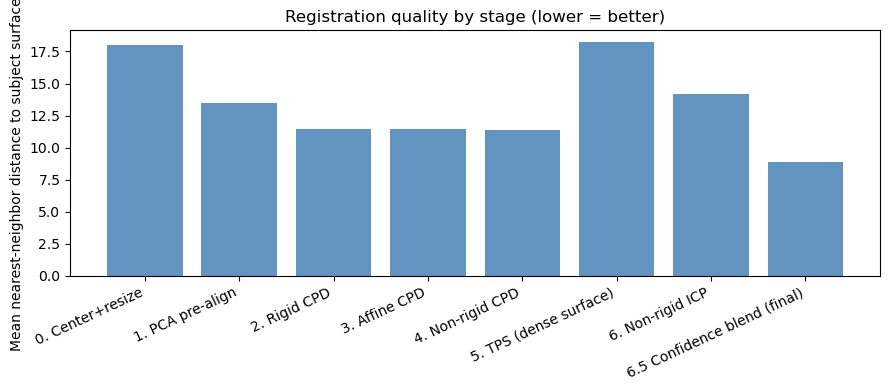

Mean surface error: 18.02 mm -> 8.90 mm (50.6% reduction)
Final Hausdorff distance: 65.51 mm


In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(summary_df['stage'], summary_df['mean'], color='steelblue', alpha=0.85)
ax.set_ylabel('Mean nearest-neighbor distance to subject surface (mm)')
ax.set_title('Registration quality by stage (lower = better)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

improvement = (summary_df.iloc[0]['mean'] - summary_df.iloc[-1]['mean']) / summary_df.iloc[0]['mean'] * 100
print(f"Mean surface error: {summary_df.iloc[0]['mean']:.2f} mm -> {summary_df.iloc[-1]['mean']:.2f} mm "
      f"({improvement:.1f}% reduction)")
print(f"Final Hausdorff distance: {summary_df.iloc[-1]['hausdorff']:.2f} mm")

## Save outputs -- write a `.vtu`

Start from the Stage-5 TPS warp applied to the **entire mesh**, then
overwrite the external-surface rows with the fully refined (ICP +
confidence-blend) result. Every node gets updated -- skull, brain, jaw,
teeth, everything -- since this notebook restores the "single warp field for
the whole model" scope. Undo center/scale/PCA to return to world
coordinates.

In [16]:
def to_world(pts_cs_pca):
    pts_cs = pts_cs_pca @ np.linalg.inv(R_pca).T   # undo PCA rotation
    return (pts_cs / scale) + c_moving             # undo scale + centering

# Start from the TPS warp for the ENTIRE mesh, then overwrite the
# external-surface rows with the fully refined (ICP + confidence-blend) result
mesh_full_final_cs = mesh_full_warped_cs.copy()
mesh_full_final_cs[external_idx_in_full] = nm_surf_final_cs

final_world_coords = to_world(mesh_full_final_cs)
updated_coords = {int(nid): xyz for nid, xyz in zip(mesh_node_ids, final_world_coords)}
print(f'Nodes to update (entire mesh): {len(updated_coords):,}')

final_mesh = template_mesh.copy()
new_points = final_mesh.points.copy()
node_id_to_idx = {int(nid): idx for idx, nid in enumerate(template_mesh.point_data['node_id'])}
for nid, xyz in updated_coords.items():
    new_points[node_id_to_idx[nid]] = xyz
final_mesh.points = new_points

OUTPUT_VTU = os.path.join(OUTPUT_DIR, 'Head_V6_full_registered.vtu')
final_mesh.save(OUTPUT_VTU)
print(f'Wrote -> {OUTPUT_VTU}')

out_csv = os.path.join(OUTPUT_DIR, 'validation_summary_full.csv')
summary_df.to_csv(out_csv, index=False)
print(f'Wrote -> {out_csv}')

Nodes to update (entire mesh): 179,676


Wrote -> /Volumes/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/cpd_tps_full_registration/Head_V6_full_registered.vtu
Wrote -> /Volumes/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/cpd_tps_full_registration/validation_summary_full.csv


## QA the written mesh (k_mesh_qa.py)

Compares against the untouched template's own baseline inverted-element count (not the raw absolute number, which includes a known ~7,100-element winding-convention artifact unrelated to registration -- see `CHANGELOG.md`).

In [17]:
sys.path.insert(0, os.path.join(BASE_DIR, 'Code'))
from k_mesh_qa import parse_k_file, check_mesh

nodes_orig, elems_solid_orig, elems_shell_orig = parse_k_file(TEMPLATE_K)
result_baseline = check_mesh(nodes_orig, elems_solid_orig, label='baseline (untouched)', elems_shell=elems_shell_orig)
baseline_bad = set(result_baseline['bad_eids'])

nodes_new = {int(nid): tuple(xyz) for nid, xyz in updated_coords.items()}
for nid, xyz in nodes_orig.items():
    if nid not in nodes_new:
        nodes_new[nid] = xyz

print(f'\nNode count  -> original: {len(nodes_orig):,}, updated: {len(nodes_new):,}')
print(f'Solid elems : {len(elems_solid_orig):,}   Shell elems: {len(elems_shell_orig):,}  (topology unchanged)')

result_new = check_mesh(nodes_new, elems_solid_orig, label=OUTPUT_VTU, elems_shell=elems_shell_orig)
new_bad = set(result_new['bad_eids'])
newly_introduced = new_bad - baseline_bad
print(f'\nNewly-introduced inverted elements (vs. untouched-template baseline): {len(newly_introduced):,}')


MESH QA: baseline (untouched)
  Nodes   : 179676
  Elements (solid/tshell): 176441
  Elements (shell)       : 80130



  NOTE: 41 of 83 parts show a mixed sign split
  internally (checked per-PID, not whole-mesh) -- flagging only the
  minority winding within each part as suspect.

  Inverted elements (negative volume): 7117
  Near-zero volume (degenerate)       : 4
  Volume stats -> min: 4.646283e-14, median: 3.433500e+00, max: 6.379447e+02
  Max/min volume ratio (proxy for aspect distortion): 6.38e+14
  ⚠ WARNING: high volume ratio -> expect LS-DYNA timestep collapse

  ⚠ FAILING ELEMENT IDs (first 20): [88058794, 88064519, 88064524, 88064533, 88064549, 88064552, 88064581, 88064627, 88064641, 88064644, 88064699, 88064715, 88064716, 88064760, 88065277, 88065280, 88065295, 88067836, 88067837, 88067838]
  -> These WILL crash or stall the LS-DYNA solver.
  -> Trace back to source vertices in your TPS/CPD warp field;
     likely cause: warp control points too sparse near this region,
     or skull/brain boundary folded during the deformation.

  --- Shell elements: 80130 ---


  Zero/near-zero area shells: 0
  Area stats -> min: 1.646016e-02, median: 8.135825e+00, max: 1.363706e+02

Node count  -> original: 179,676, updated: 179,676
Solid elems : 176,441   Shell elems: 80,130  (topology unchanged)

MESH QA: /Volumes/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/cpd_tps_full_registration/Head_V6_full_registered.vtu
  Nodes   : 179676
  Elements (solid/tshell): 176441
  Elements (shell)       : 80130



  NOTE: 53 of 83 parts show a mixed sign split
  internally (checked per-PID, not whole-mesh) -- flagging only the
  minority winding within each part as suspect.

  Inverted elements (negative volume): 9596
  Near-zero volume (degenerate)       : 0
  Volume stats -> min: 1.161502e-05, median: 3.161659e+00, max: 5.809869e+03
  Max/min volume ratio (proxy for aspect distortion): 5.00e+08
  ⚠ WARNING: high volume ratio -> expect LS-DYNA timestep collapse

  ⚠ FAILING ELEMENT IDs (first 20): [88058794, 88064435, 88064439, 88064440, 88064441, 88064442, 88064519, 88064524, 88064533, 88064549, 88064552, 88064581, 88064627, 88064641, 88064644, 88064699, 88064715, 88064716, 88064760, 88064771]
  -> These WILL crash or stall the LS-DYNA solver.
  -> Trace back to source vertices in your TPS/CPD warp field;
     likely cause: warp control points too sparse near this region,
     or skull/brain boundary folded during the deformation.

  --- Shell elements: 80130 ---


  Zero/near-zero area shells: 0
  Area stats -> min: 1.193480e-03, median: 7.553988e+00, max: 2.368022e+03

Newly-introduced inverted elements (vs. untouched-template baseline): 3,513
